In [1]:
import pandas as pd
import numpy as np 

In [2]:
#student_attendance=pd.read_csv("student_attendance.csv")
student_masters=pd.read_csv("student_master_500.csv")

In [3]:
student_masters

,student_id,age,gender,department,study_hours,attendance,sleep_hours,previous_gpa,assignments_completed,internet_hours,extracurricular_hours,monthly_expense,parent_education,part_time_job,exam_score
0,1,19,Male,CSE,9.03,88.52,8.28,3.37,10,6.42,2.17,24590.92,Bachelor,No,100.00
1,2,24,Male,CSE,7.96,57.99,6.27,3.46,7,4.72,1.75,14932.36,Master,No,100.00
2,3,20,Female,AIML,8.91,80.13,6.69,2.51,4,4.88,2.97,11762.93,Bachelor,No,100.00
3,4,18,Female,MECH,7.07,92.97,5.93,1.74,10,4.91,2.45,25007.81,Master,No,100.00
4,5,23,Female,CSE,5.82,88.64,4.86,2.72,8,4.20,2.52,25512.60,Bachelor,No,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,25,Male,ECE,7.27,88.59,5.75,3.21,10,7.28,1.18,24904.32,Master,No,100.00
496,497,19,Male,MECH,3.46,70.17,6.94,3.62,2,4.97,2.15,5000.00,Master,Yes,91.43
497,498,20,Female,ECE,5.48,87.40,6.73,2.59,10,1.78,2.70,20027.48,Bachelor,No,100.00
498,499,19,Female,CSE,6.22,80.44,6.24,3.52,2,5.99,0.81,25125.74,Bachelor,No,100.00


In [4]:
student_masters.info()
#THERE ARE LOT OF FEATURES AND OUR MAIN FEATURE IS GOING TO BE EXAM SCORE AS WE ARE GOING TO PREDICT EXAM SCORE BY TAKING THE OTHERS FEATURES AS INPUT 

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             500 non-null    int64  
 1   age                    500 non-null    int64  
 2   gender                 500 non-null    str    
 3   department             500 non-null    str    
 4   study_hours            500 non-null    float64
 5   attendance             500 non-null    float64
 6   sleep_hours            496 non-null    float64
 7   previous_gpa           496 non-null    float64
 8   assignments_completed  500 non-null    int64  
 9   internet_hours         497 non-null    float64
 10  extracurricular_hours  500 non-null    float64
 11  monthly_expense        498 non-null    float64
 12  parent_education       497 non-null    str    
 13  part_time_job          500 non-null    str    
 14  exam_score             500 non-null    float64
dtypes: float64(8), in

In [5]:
student_masters.isnull().sum()
# THERE ARE EMPTY VALUES IN COLUMNS - SLEEP_HOURS,PREVIOUS_GPA,INTERNET_HOURS,MONTHLY_EXPENSE,PARENTEDUCATION 
#SO NOW WE ARE GOING TO FILL THE EMPTY COLUMNS ACCORDING TO ITS DATA TYPE 

student_id               0
age                      0
gender                   0
department               0
study_hours              0
attendance               0
sleep_hours              4
previous_gpa             4
assignments_completed    0
internet_hours           3
extracurricular_hours    0
monthly_expense          2
parent_education         3
part_time_job            0
exam_score               0
dtype: int64

In [13]:
student_masters["sleep_hours"]=student_masters["sleep_hours"].fillna(student_masters["sleep_hours"].mean(),inplace=True)

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1845460706.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  student_masters["sleep_hours"]=student_masters["sleep_hours"].fillna(student_masters["sleep_hours"].mean(),inplace=True)


In [16]:
student_masters["previous_gpa"]=student_masters["previous_gpa"].fillna(student_masters["previous_gpa"].mean())

In [58]:
student_masters.info()
student_masters["internet_hours"]=student_masters["internet_hours"].fillna(student_masters["monthly_expense"].mode()[0]).isna()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             500 non-null    int64  
 1   age                    500 non-null    int64  
 2   gender                 500 non-null    str    
 3   department             500 non-null    str    
 4   study_hours            500 non-null    float64
 5   attendance             500 non-null    float64
 6   sleep_hours            500 non-null    float64
 7   previous_gpa           500 non-null    float64
 8   assignments_completed  500 non-null    int64  
 9   internet_hours         500 non-null    bool   
 10  extracurricular_hours  500 non-null    float64
 11  monthly_expense        500 non-null    float64
 12  parent_education       497 non-null    str    
 13  part_time_job          500 non-null    str    
 14  exam_score             500 non-null    float64
dtypes: bool(1), float

In [59]:
def fill_mean(series):
    return series.fillna(series.mean())

In [60]:
student_masters["monthly_expense"]=fill_mean(student_masters["monthly_expense"])

In [69]:
student_masters.info()
student_masters["parent_education"]=student_masters["parent_education"].fillna(student_masters["parent_education"].mode()[0])

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             500 non-null    int64  
 1   age                    500 non-null    int64  
 2   gender                 500 non-null    str    
 3   department             500 non-null    str    
 4   study_hours            500 non-null    float64
 5   attendance             500 non-null    float64
 6   sleep_hours            500 non-null    float64
 7   previous_gpa           500 non-null    float64
 8   assignments_completed  500 non-null    int64  
 9   internet_hours         500 non-null    bool   
 10  extracurricular_hours  500 non-null    float64
 11  monthly_expense        500 non-null    float64
 12  parent_education       497 non-null    str    
 13  part_time_job          500 non-null    str    
 14  exam_score             500 non-null    float64
dtypes: bool(1), float

In [72]:
student_masters.info()
# SO NOW ALL THE MISSING DATA IS TOTALLY FILLED:
# THE NUMERIC DATA IS FILLED WITH THE AVERAGE VALUE OF THAT COLUMN 
# THE STRING DATA IS FILLED WITH THE MOST REPEATED DATA 

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             500 non-null    int64  
 1   age                    500 non-null    int64  
 2   gender                 500 non-null    str    
 3   department             500 non-null    str    
 4   study_hours            500 non-null    float64
 5   attendance             500 non-null    float64
 6   sleep_hours            500 non-null    float64
 7   previous_gpa           500 non-null    float64
 8   assignments_completed  500 non-null    int64  
 9   internet_hours         500 non-null    bool   
 10  extracurricular_hours  500 non-null    float64
 11  monthly_expense        500 non-null    float64
 12  parent_education       500 non-null    str    
 13  part_time_job          500 non-null    str    
 14  exam_score             500 non-null    float64
dtypes: bool(1), float

In [84]:
student_masters.drop_duplicates(inplace=True)
#IT SEEMS THERE IS NO DUPLICATE VALUES IN THE ROW SO WE PROCEED TO NEXT 

In [86]:
student_masters.columns

Index(['student_id', 'age', 'gender', 'department', 'study_hours',
       'attendance', 'sleep_hours', 'previous_gpa', 'assignments_completed',
       'internet_hours', 'extracurricular_hours', 'monthly_expense',
       'parent_education', 'part_time_job', 'exam_score'],
      dtype='str')

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


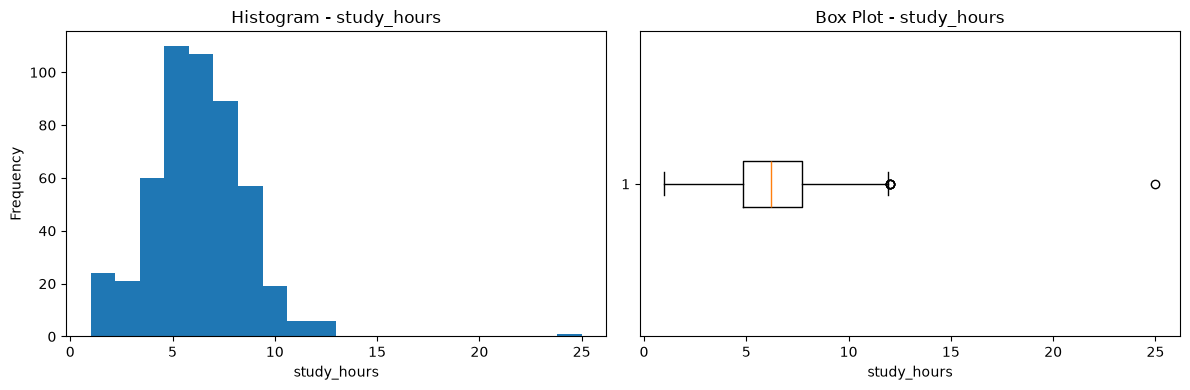

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


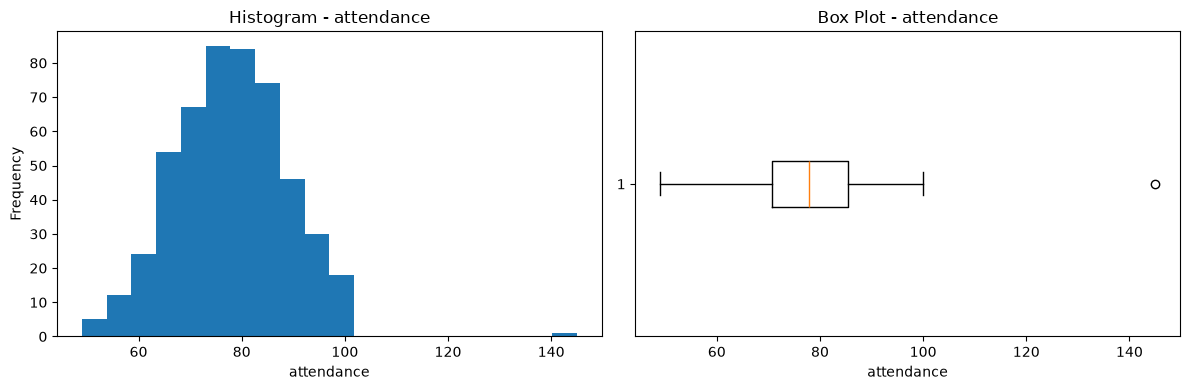

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


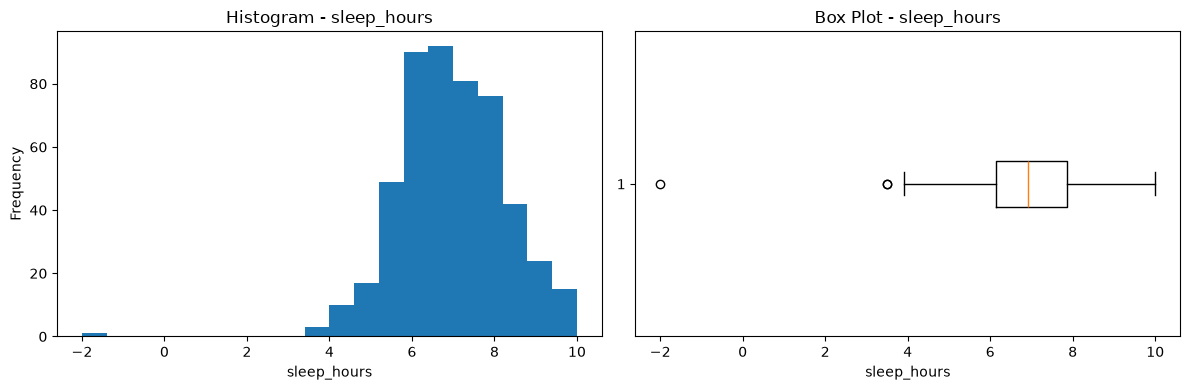

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


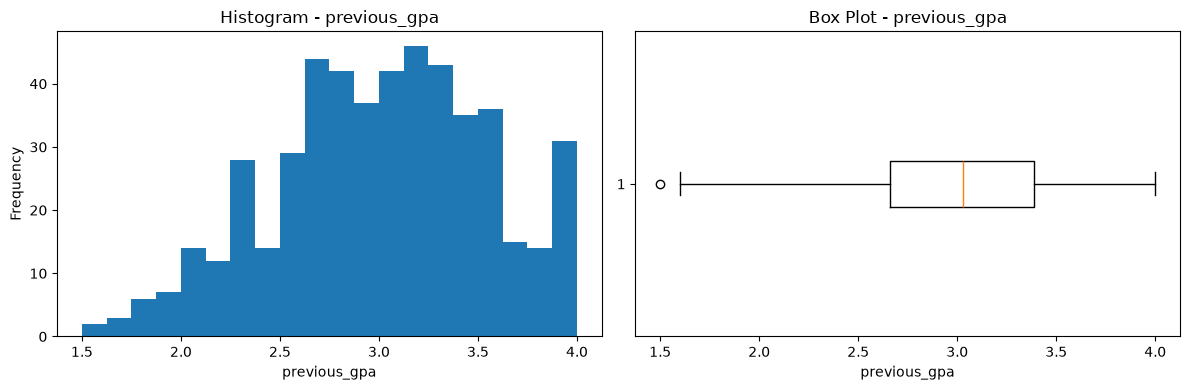

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


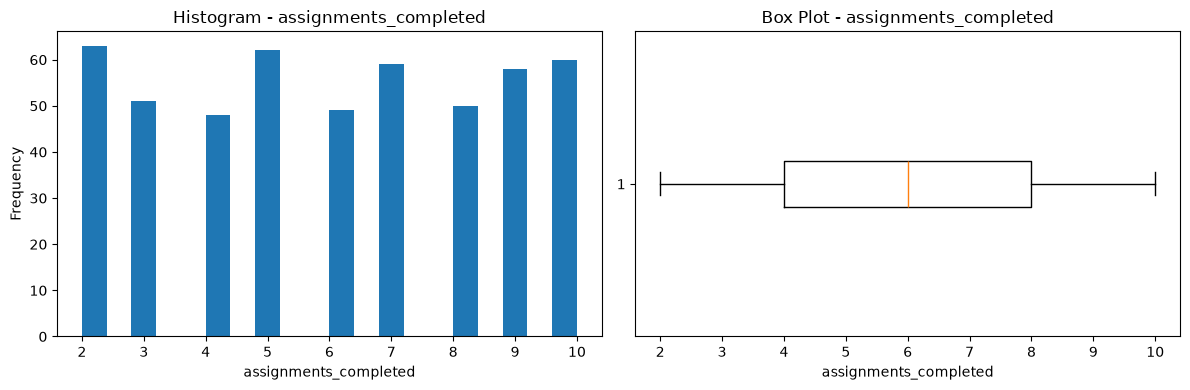

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


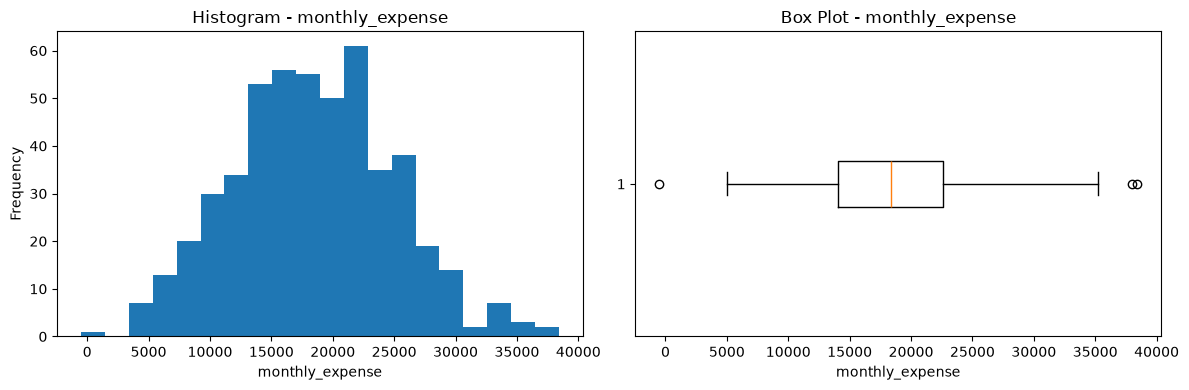

C:\Users\My PC\AppData\Local\Temp\ipykernel_117380\1476051565.py:26: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(student_masters[column].dropna(), vert=False)


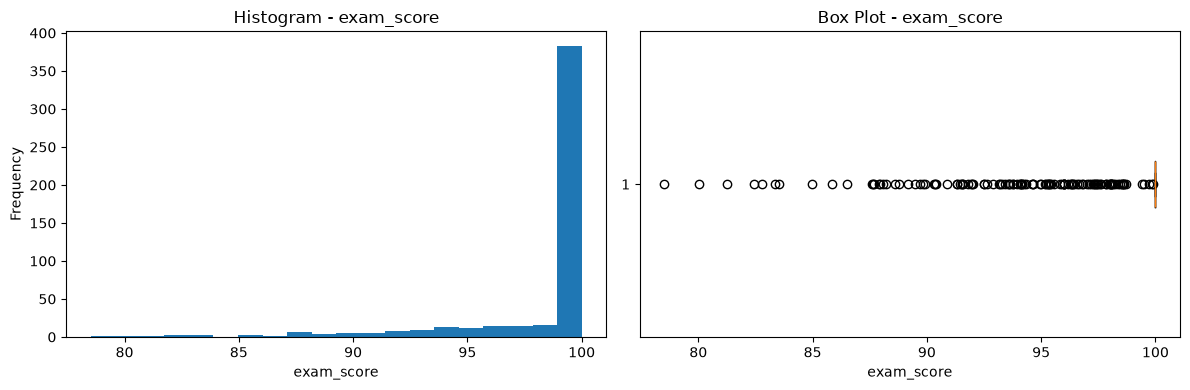

In [94]:
# it seems that there is no any inconsistnt value in the data now we are moving towards outliers 
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    "study_hours",
    "attendance",
    "sleep_hours",
    "previous_gpa",
    "assignments_completed",
    "monthly_expense",
    "exam_score"
]

for column in columns:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(student_masters[column].dropna(), bins=20)
    axes[0].set_title(f"Histogram - {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")

    # Box Plot
    axes[1].boxplot(student_masters[column].dropna(), vert=False)
    axes[1].set_title(f"Box Plot - {column}")
    axes[1].set_xlabel(column)

    plt.tight_layout()
    plt.show()